# Classificazione con K-Nearest Neighbors (KNN) e Support Vector Machine (SVM)

Questo notebook esplora il dataset **Wine** applicando due algoritmi di classificazione supervisionata: **K-Nearest Neighbors (KNN)** e **Support Vector Machine (SVC)**.

L'obiettivo è addestrare e confrontare i due classificatori, valutarne le performance e visualizzare le regioni di decisione nello spazio ridotto dalla PCA.

### Dataset

| Tipo | Variabili | Descrizione |
|------|-----------|-------------|
| **Features (X)** | 13 misurazioni chimiche | Alcol, acido malico, cenere, flavonoidi, proline, ecc. |
| **Target (y)** | `class_0`, `class_1`, `class_2` | Tre coltivazioni di vino prodotti nella stessa regione italiana |

### Pipeline di Analisi

1. **Caricamento ed esplorazione** del dataset con statistiche descrittive
2. **Preprocessing**: standardizzazione con `StandardScaler` e riduzione dimensionale con `PCA` a 2 componenti
3. **Addestramento** di `KNN` e `SVC` sullo spazio PCA 2D
4. **Visualizzazione predizioni**: scatter plot con evidenziazione dei punti misclassificati
5. **Decision boundary**: regioni di decisione e curve di livello di probabilità per entrambi i modelli

## Import & Configurazione

In [1]:
# IMPORT E CONFIGURAZIONE STILE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

# --- Configurazione stile Matplotlib ---
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    # Figura
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    # Font
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    # Assi
    'axes.spines.top': False,
    'axes.spines.right': False,
    # Linee e marker
    'lines.linewidth': 2,
    'lines.markersize': 7,
    # Legenda
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.fontsize': 10
})

COLOR = {
    'blue': '#2196F3',
    'red': '#E91E63',
    'green': '#4CAF50',
    'yellow': '#FF9800',
    'purple': '#9C27B0'
}

# --- Configurazione stile tabelle ---
table_style = [
        {'selector': 'caption', 'props': [
            ('font-size', '13px'), ('font-weight', 'bold'),
            ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',      'props': [
            ('background-color', '#1565C0'), ('color', 'white'),
            ('font-size', '12px'), ('text-align', 'center'),
            ('padding', '6px 12px')]},
        {'selector': 'td',      'props': [
            ('text-align', 'center'), ('padding', '5px 12px'),
            ('font-size', '12px')]},
    ]

## Caricamento e Descrizione Dataset

In [ ]:
# CARICAMENTO DATASET WINE

print('='*80)
print('DATASET WINE'.center(80))
print('='*80 + '\n')

# Caricamento dati
data_wine = load_wine()

# Descrizione completa del dataset
print(data_wine.DESCR)
print('-'*80 + '\n')

# --- Features ---
print('Features')
print('-'*80)
features = data_wine.data
features_names = data_wine.feature_names

print('\nDimensioni features:')
print(features.shape)
print('\nNomi features:')
for name in features_names:
    print(f'  - {name}')
print('\nCampione dati features:')
print(features[:5])
print('-'*80 + '\n')

# --- Target ---
print('Target')
print('-'*80)
target_data = data_wine.target
target_names = data_wine.target_names

print('\nDimensioni target:')
print(target_data.shape)
print('\nNomi target:')
for name in target_names:
    print(f'  - {name}')
print('\nCampione dati target:\n')
print(target_data[:5])
print('='*80)


                                  DATASET WINE                                  

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:         

## Statistiche Descrittive

In [49]:
# STATISTICHE DEL DATASET

# Conversione features e target in DataFrame
df_feat = pd.DataFrame(features, columns=features_names)
df_target = pd.DataFrame(target_data, columns=['label'])

print('='*80)
print('STATISTICHE DEL DATASET'.center(80))
print('='*80 + '\n')

# --- Statistiche descrittive delle features ---
print('Features')
print('-'*80)
print('Statistiche descrittive:\n')
print(df_feat.describe().round(2).T.to_string(max_colwidth=15))
X = df_feat.to_numpy()
print('-'*80 + '\n')

# --- Distribuzione delle classi target ---
print('Target')
print('-'*80)
target_values = df_target['label'].unique()
total_target = df_target['label'].count()
y = df_target['label'].to_numpy()

print('Distribuzione delle classi:\n')
for label, name_label in zip(target_values, target_names):
    count_label = df_target[df_target['label'] == label]['label'].count()
    print(f'  - {name_label.capitalize():<10}: {count_label/total_target:.2%}')
    
print('='*80)


                            STATISTICHE DEL DATASET                             

Features
--------------------------------------------------------------------------------
Statistiche descrittive:

                 count    mean     std     min     25%     50%     75%      max
alcohol          178.0   13.00    0.81   11.03   12.36   13.05   13.68    14.83
malic_acid       178.0    2.34    1.12    0.74    1.60    1.87    3.08     5.80
ash              178.0    2.37    0.27    1.36    2.21    2.36    2.56     3.23
alcalinity_o...  178.0   19.49    3.34   10.60   17.20   19.50   21.50    30.00
magnesium        178.0   99.74   14.28   70.00   88.00   98.00  107.00   162.00
total_phenols    178.0    2.30    0.63    0.98    1.74    2.36    2.80     3.88
flavanoids       178.0    2.03    1.00    0.34    1.20    2.13    2.88     5.08
nonflavanoid...  178.0    0.36    0.12    0.13    0.27    0.34    0.44     0.66
proanthocyanins  178.0    1.59    0.57    0.41    1.25    1.56    1.95     3.58
co

## Preprocessing Dataset

Prima di addestrare i modelli è necessario preparare i dati in due fasi.

**Standardizzazione** (`StandardScaler`): le 13 features del dataset Wine hanno scale molto diverse (es. `proline` varia tra 278 e 1680, mentre `nonflavanoid_phenols` tra 0.13 e 0.66). Senza normalizzazione, i modelli basati su distanze come KNN sarebbero dominati dalle features con range maggiore, distorcendo il calcolo dei vicini. La stessa sensibilità alla scala si applica a SVC, dove il margine di separazione dipende dalle distanze nello spazio delle features.

**PCA** (Principal Component Analysis): riduce le 13 features originali a 2 componenti principali, rendendo possibile la visualizzazione dello spazio delle features e delle regioni di decisione in un piano 2D. La proiezione viene applicata ai dati già standardizzati, garantendo che tutte le features contribuiscano equamente alla decomposizione.

In [19]:
# STANDARDIZZAZIONE & PCA 2D FEATURES 

print('='*80)
print('PREPROCESSING FEATURES'.center(80))
print('='*80 + '\n')

# --- Standardizzazione Features ---
print('Standardizzazione Features')
print('-'*80)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
for i, name in enumerate(features_names):
    print(f'\nFeature {name.capitalize()}:\n')
    print(f'  - Media    :  {X_scaled[:,i].mean():.2e}')
    print(f'  - Dev. std :  {X_scaled[:,i].std():.2f}')

print('-'*80)

# --- Proiezione PCA 2D --- 
print('\nApplicazione PCA alle Features')
print('-'*80)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_

print('\nVarianza spiegata PC Features:\n')
for i, ratio in enumerate(pca.explained_variance_ratio_): 
    print(f'  - PC{i+1}: {ratio:.2%}')

print('='*80)


                             PREPROCESSING FEATURES                             

Standardizzazione Features
--------------------------------------------------------------------------------

Feature Alcohol:

  - Media    :  7.94e-15
  - Dev. std :  1.00

Feature Malic_acid:

  - Media    :  3.59e-16
  - Dev. std :  1.00

Feature Ash:

  - Media    :  -4.07e-15
  - Dev. std :  1.00

Feature Alcalinity_of_ash:

  - Media    :  -7.98e-17
  - Dev. std :  1.00

Feature Magnesium:

  - Media    :  -7.98e-17
  - Dev. std :  1.00

Feature Total_phenols:

  - Media    :  -3.99e-17
  - Dev. std :  1.00

Feature Flavanoids:

  - Media    :  9.98e-16
  - Dev. std :  1.00

Feature Nonflavanoid_phenols:

  - Media    :  -5.59e-16
  - Dev. std :  1.00

Feature Proanthocyanins:

  - Media    :  -1.66e-15
  - Dev. std :  1.00

Feature Color_intensity:

  - Media    :  -3.44e-16
  - Dev. std :  1.00

Feature Hue:

  - Media    :  1.64e-15
  - Dev. std :  1.00

Feature Od280/od315_of_diluted_wines:

  -

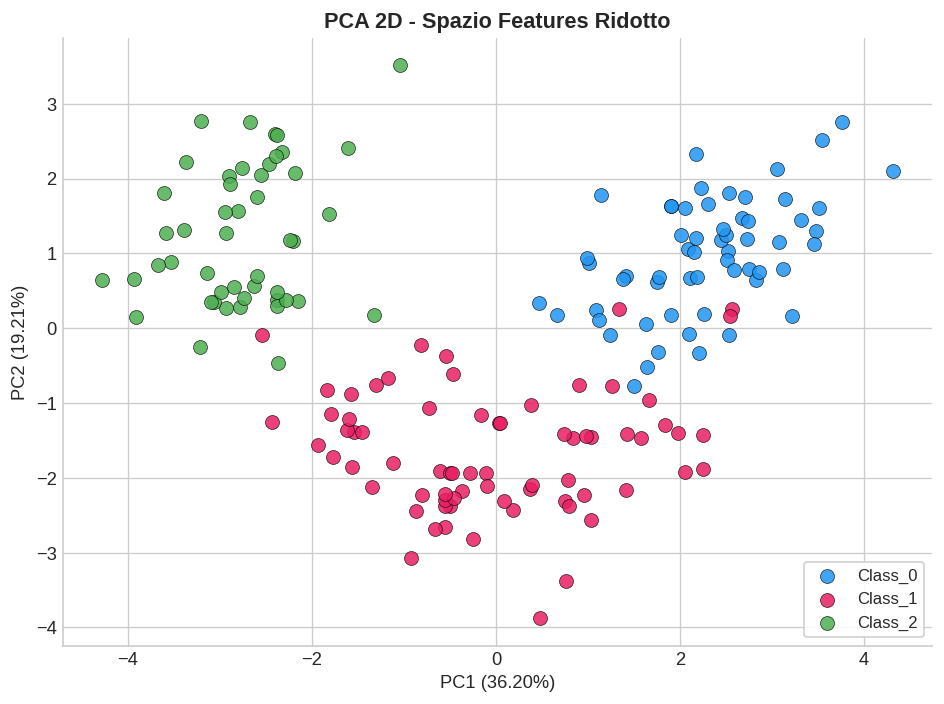

In [20]:
# VISUALIZZAZIONE - SPAZIO PCA

# Definizione palette
palette = [COLOR['blue'], COLOR['red'], COLOR['green']]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

# Per ogni specie classe...
for i, name in enumerate(target_names):
    mask = target_data == i
    
    # Scatter classe selezionata
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=palette[i], 
        label=name.capitalize(),
        edgecolors='k', linewidths=0.4, s=70, alpha=0.85
    )

ax.set_title('PCA 2D - Spazio Features Ridotto')
ax.set_xlabel(f'PC1 ({var1:.2%})')
ax.set_ylabel(f'PC2 ({var2:.2%})')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Osservazioni

Nonostante PC1 e PC2 spieghino complessivamente solo il ~55% della varianza totale, la proiezione 2D riesce comunque a separare le tre classi in modo sufficientemente nitido per la classificazione.

Le tre classi formano gruppi ben distinti nello spazio PCA con una sovrapposizione limitata. Questo suggerisce che le prime due componenti principali catturano le direzioni di variabilità più discriminanti tra i vitigni, rendendo la rappresentazione 2D adeguata per addestrare e visualizzare i classificatori nonostante la considerevole perdita di informazione.

## Addestramento Modelli

In [ ]:
# ADDESTRAEMENTO MODELLI

print('='*80)
print('ADDESTRAMENTO MODELLI'.center(80))
print('='*80 + '\n')

# --- KNN ---
print('Classificatore KNN')
knn = KNeighborsClassifier(n_neighbors=5)

# Fit
knn.fit(X_pca, y)

# Predict
y_pred_knn = knn.predict(X_pca)
y_proba_knn = knn.predict_proba(X_pca)

# Evaluate
knn_accuracy = accuracy_score(y, y_pred_knn) 
misclassified_knn = y_pred_knn != y

print(f'  - Accuracy: {knn_accuracy:.3f}')
print(f'  - Errori:   {misclassified_knn.sum()} ({(misclassified_knn.sum()/misclassified_knn.size):.2%})')
print('-'*80 + '\n')

# --- SVC ---
print('Classificatore SVC')
svc = SVC(kernel='linear', probability=True)

# Fit
svc.fit(X_pca, y)

# Predict
y_pred_svc = svc.predict(X_pca)
y_proba_svc = svc.predict_proba(X_pca)

# Evaluate
svc_accuracy = accuracy_score(y, y_pred_svc)
misclassified_svc = y_pred_svc != y

print(f'  - Accuracy: {svc_accuracy:.3f}')
print(f'  - Errori  : {misclassified_svc.sum()} ({(misclassified_svc.sum()/misclassified_svc.size):.2%})')
print('='*80)

                             ADDESTRAMENTO MODELLI                              

Classificatore KNN
  - Accuracy: 0.966
  - Errori:   6 (3.37%)
--------------------------------------------------------------------------------

Classificatore SVC
  - Accuracy: 0.972
  - Errori  : 5 (2.81%)


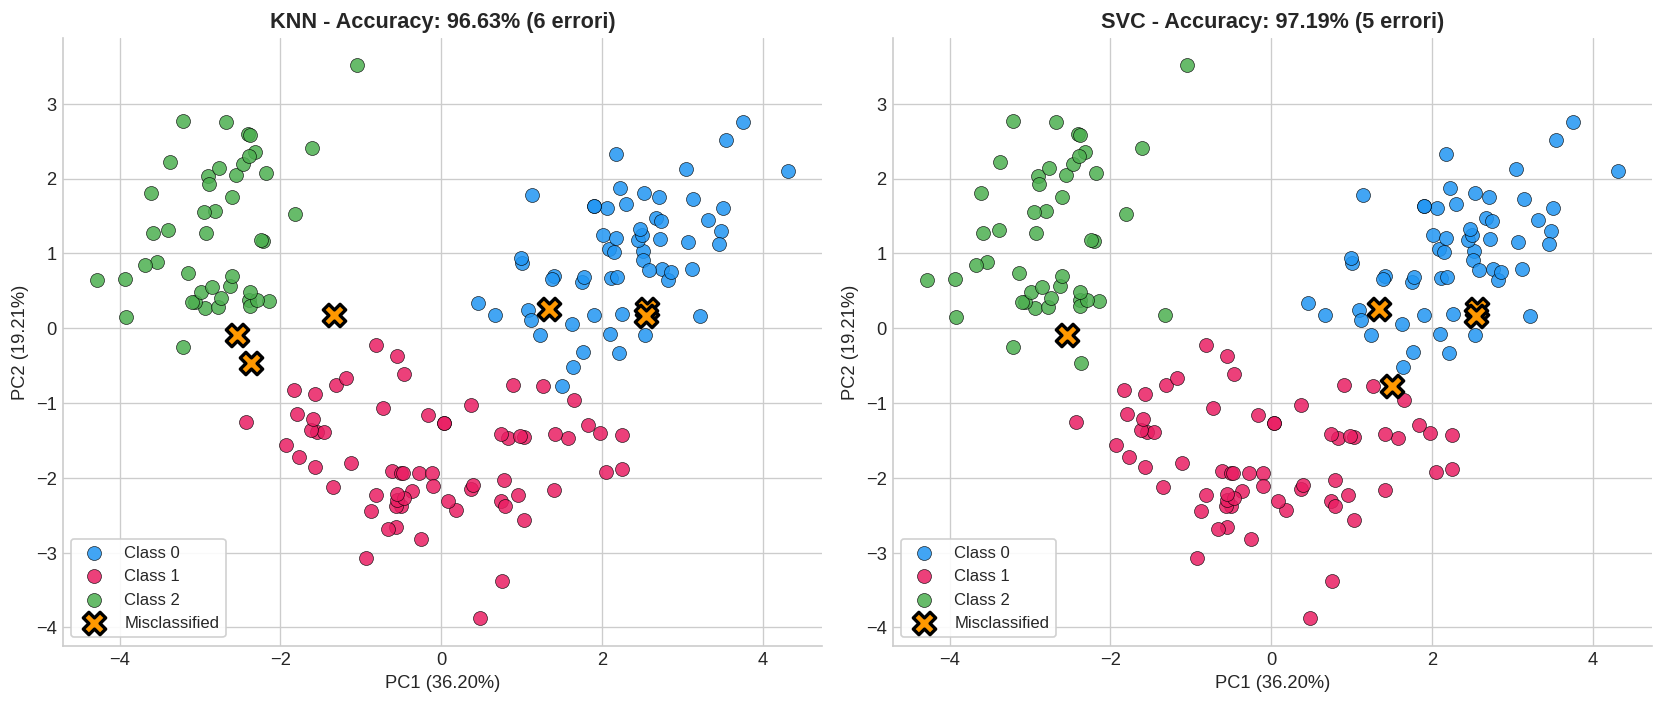

In [ ]:
# VISUALIZZAZIONI PREDIZIONI

# Definizione palette
palette = [COLOR['blue'], COLOR['red'], COLOR['green']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, misclassified, model_name, accuracy in zip(
    axes,
    [y_pred_knn, y_pred_svc],
    [misclassified_knn, misclassified_svc],
    ['KNN', 'SVC'],
    [knn_accuracy, svc_accuracy]
    ):
    # Punti classificati correttamente
    for label in sorted(set(y_pred)):
        mask = (y_pred == label) & ~misclassified
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            color=palette[label % len(palette)],
            label=f'Class {label}',
            edgecolors='k', linewidths=0.4, s=70, alpha=0.85
        )

    # Punti misclassificati
    ax.scatter(
        X_pca[misclassified, 0], X_pca[misclassified, 1],
        facecolors=COLOR['yellow'], edgecolors='black',
        linewidths=2, s=180, marker='X',
        label='Misclassified', zorder=5
    )

    n_errors = misclassified.sum()
    ax.set_title(f'{model_name} - Accuracy: {accuracy:.2%} ({n_errors} errori)')
    ax.set_xlabel(f'PC1 ({var1:.2%})')
    ax.set_ylabel(f'PC2 ({var2:.2%})')
    ax.legend()

plt.tight_layout()
plt.show()

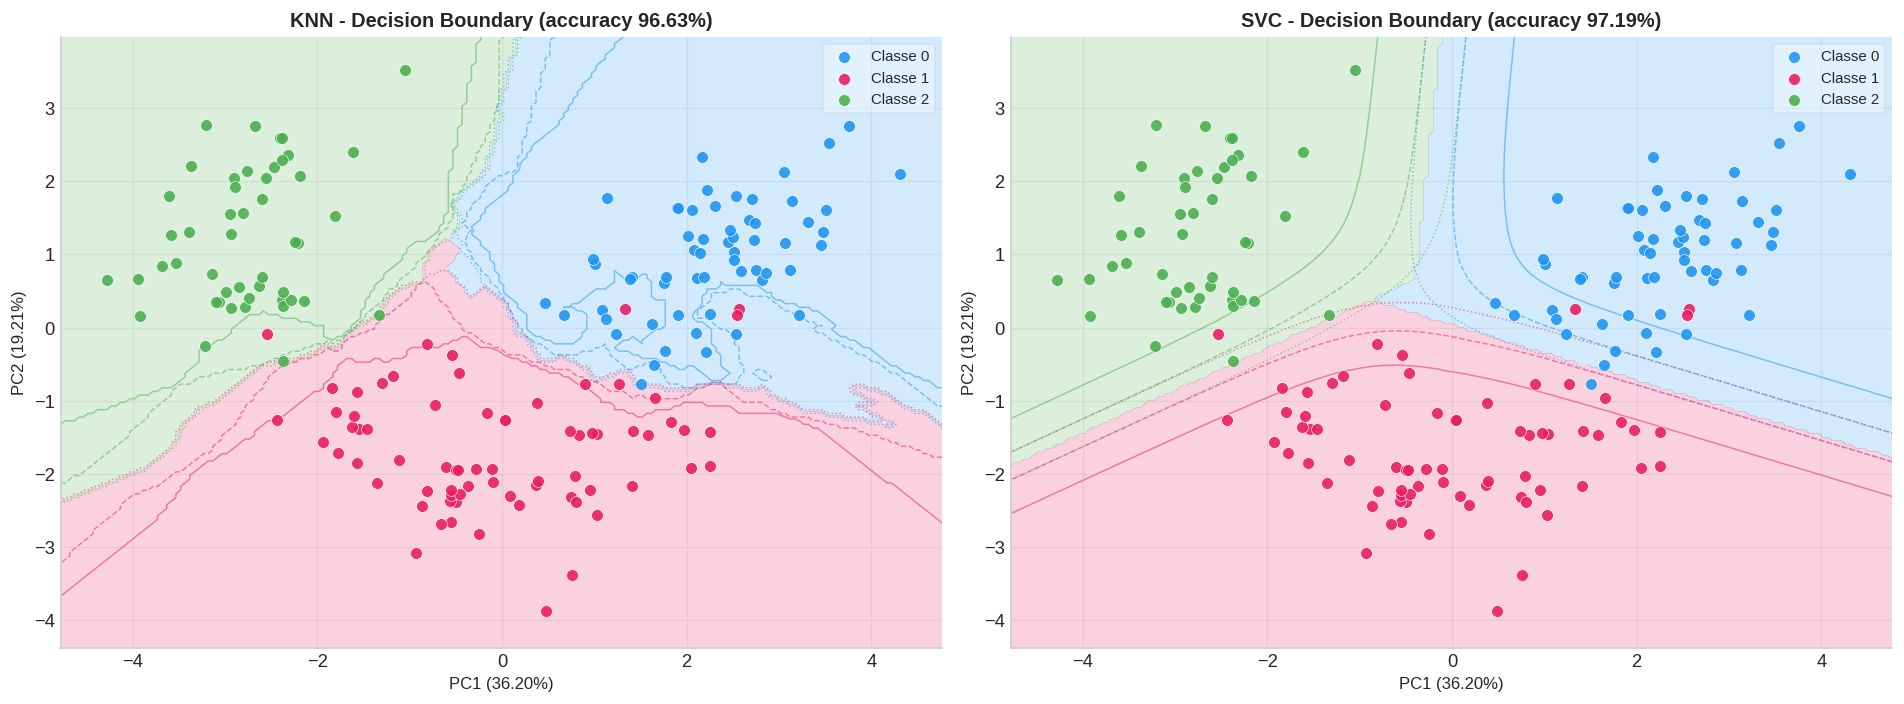

In [ ]:
# DECISION BOUNDARY & CURVE DI LIVELLO

def plot_decision_boundary_2d(
    classifier,
    X: np.ndarray,
    y_true: np.ndarray,
    ax: plt.Axes,
    resolution: float = 0.05,
    title: str = '',
    alpha_bg: float = 0.20,
) -> None:
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, resolution),
        np.arange(y_min, y_max, resolution),
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    Z     = classifier.predict(grid_points).reshape(xx.shape)
    proba = classifier.predict_proba(grid_points)          # (n_grid, n_classes)

    classes   = np.unique(y_true)
    pt_colors = [COLOR['blue'], COLOR['red'], COLOR['green']]

    # Sfondo regioni di decisione
    for c, color in zip(classes, pt_colors):
        ax.contourf(
            xx, yy, (Z == c).astype(float),
            levels=[0.5, 1.5], colors=[color], alpha=alpha_bg
        )

    # Curve di livello probabilità per ogni classe
    contour_levels = [0.4, 0.6, 0.8]
    for c, color in zip(classes, pt_colors):
        P = proba[:, c].reshape(xx.shape)
        cs = ax.contour(
            xx, yy, P, levels=contour_levels,
            colors=[color], linewidths=0.9, alpha=0.5,
            linestyles=[':', '--', '-']
        )

    # Scatter con vere etichette
    for c, color in zip(classes, pt_colors):
        mask = y_true == c
        ax.scatter(
            X[mask, 0], X[mask, 1],
            c=color, label=f'Classe {c}',
            s=50, alpha=0.90,
            edgecolors='white', linewidths=0.4, zorder=3
        )

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var1:.2%})', fontsize=10)
    ax.set_ylabel(f'PC2 ({var2:.2%})', fontsize=10)
    ax.legend(fontsize=9, loc='best', framealpha=0.35)
    ax.grid(True, alpha=0.3)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundary_2d(
    knn, X_pca, y, axes[0],
    title=f'KNN - Decision Boundary (accuracy {knn_accuracy:.2%})'
)
plot_decision_boundary_2d(
    svc, X_pca, y, axes[1],
    title=f'SVC - Decision Boundary (accuracy {svc_accuracy:.2%})'
)

plt.tight_layout()
plt.show()

## Conclusioni

Entrambi i modelli raggiungono performance elevate: **KNN** ottiene un'accuratezza del **96.6%** (6 errori) e **SVC** del **97.2%** (5 errori).

Tuttavia, l'analisi delle regioni di decisione rivela differenze strutturali importanti tra i due modelli:

- **KNN**: il confine di decisione è frastagliato e irregolare, con regioni dalla geometria complessa che si adattano ai dati. Le curve di livello di probabilità mostrano zone di incertezza altamente localizzate, sintomo di potenziale **overfitting**: il modello potrebbe non generalizzare bene su dati non visti.

- **SVC con kernel lineare**: il confine di decisione è netto e lineare, con curve di livello regolari e graduate. Questa semplicità strutturale lo rende più robusto e interpretabile, con maggiore probabilità di generalizzare su nuovi campioni.

**SVC lineare** rappresenta la scelta più robusta per questo dataset grazie alla sua capacità di costruire confini di decisione stabili e generalizzabili.